In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/피싱사이트 URL목록_(22년 09월_11월).csv')
df

,날짜,홈페이지주소
0,09월 01일,http://masf.krhes.boston
1,09월 01일,con08.nu8w.love 외11건
2,09월 01일,coz.ul3u.show
3,09월 01일,https://donate.do/h73t
4,09월 01일,oabe.fyy8.plus
...,...,...
1981,11월 30일,https://nanourl.org/GfJ
1982,11월 30일,http://tuc.bit7.ink
1983,11월 30일,http://hrc.wtbj.hair
1984,11월 30일,http://kut31.xvys.hair


#1. 사전 단어 라이브러리 호출

In [2]:
import nltk
from nltk.corpus import words

# NLTK 단어 리스트 다운로드 (최초 1회 필요)
nltk.download('words')

# 영어 단어 리스트 가져오기
english_words = set(words.words())

# 일부 출력
print(list(english_words)[:10])  # ['abilities', 'frustrated', 'beautiful', ...]


[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


['desistive', 'phleboplasty', 'untreatableness', 'tuberculoprotein', 'nesslerization', 'psalterial', 'embodier', 'revelly', 'etiogenic', 'gravamen']


#2. 리스트 내에 의미있는 단어 개수 카운팅 함수

In [3]:
def meaning_count(words,english_words):
  counting = 0
  for word in words:
    if word in english_words:
      counting += 1
  return counting

In [ ]:
df['split_words'] = df['홈페이지주소'].str.split(r'[/.]',regex=True)
df['number_of_meaning_words'] = df['split_words'].apply(lambda word_list: meaning_count(word_list,english_words))
df[df['number_of_meaning_words']==0]

,날짜,홈페이지주소,split_words,number_of_meaning_words
1,09월 01일,con08.nu8w.love 외11건,"[con08, nu8w, love 외11건]",0
12,09월 02일,http://hgfdh.bsone.kr,"[http:, , hgfdh, bsone, kr]",0
13,09월 02일,http://hg6if.spoet.kr,"[http:, , hg6if, spoet, kr]",0
14,09월 02일,oanxz.g6ho.cyou,"[oanxz, g6ho, cyou]",0
16,09월 02일,http://lsopfi.zmgec.mobi/,"[http:, , lsopfi, zmgec, mobi, ]",0
...,...,...,...,...
1963,11월 29일,https://nanourl.org/j3g,"[https:, , nanourl, org, j3g]",0
1966,11월 29일,http://hjtccb.wuny.casa,"[http:, , hjtccb, wuny, casa]",0
1970,11월 29일,http://htyrc.bit7.uno,"[http:, , htyrc, bit7, uno]",0
1981,11월 30일,https://nanourl.org/GfJ,"[https:, , nanourl, org, GfJ ]",0


#3. 무작위 단어 추출 > n-gram entropy 이용
https://github.com/nltk/nltk/issues/2961 > 코드 사이트  

https://velog.io/@tobigs-text1314/CS224n-Lecture-6-Language-Models-and-Recurrent-Neural-Network > 개념 사이트

In [ ]:
'''
ngram 생성, 앤트로피, perplexity 반환하는 클래스 생성
'''
import pandas as pd
import numpy as np
class URLLanguageModel:
  def __init__(self,n):
    self.n = n #n-gram 크기 설정

  def _mean(self, items):
    return sum(items) / len(items) #모델 예측 성능 평균

  def _generate_ngrams(self,text):
    ngrams = []
    for i in range(len(text) - self.n+1):
    #예를들어 My name is hyunseo 이고 2개씩 단어를 묶을때...
    #(My, name), (name, is), (is, hyunseo) 4-2+1=3
      ngrams.append(tuple(text[i:i+self.n])) #ngram 생성
    return ngrams

  def logscore(self, word, context):
    return np.random.uniform(-5, 0)  # -5와 0 사이의 랜덤 값 반환

  def entropy(self, text_ngrams):
    return -1 * self._mean(
        [self.logscore(ngram[-1], ngram[:-1]) for ngram in text_ngrams]
    )

  def calculate_perplexity(self, text):
    text_ngrams = self._generate_ngrams(text)
    log_probabilities = [
        self.logscore(ngram[-1],ngram[:-1]) for ngram in text_ngrams
    ]
    entropy_value = -1 * self._mean(log_probabilities)
    return np.exp(entropy_value)
  def analyze_word_complexity(self, word):
        chars = list(word.lower())
        char_ngrams = self._generate_ngrams(chars)
        complexity = {
            'word': word,
            'length': len(word),
            'char_entropy': self.entropy(char_ngrams),
            'char_perplexity': self.calculate_perplexity(char_ngrams)
        }

        return complexity

In [ ]:
model = URLLanguageModel(n=2)
entropy_values = []
Perplexity = []
for index, row in df.iterrows():
  url = row['홈페이지주소']
  text = list(url)
  text_ngrams = model._generate_ngrams(text)
  entropy_value = model.entropy(text_ngrams)
  entropy_values.append(entropy_value)
  perplexity_value = model.calculate_perplexity(text)
  Perplexity.append(perplexity_value)
df['entropy_value'] = entropy_values
df['Perplexity'] = Perplexity

In [ ]:
df[df['entropy_value']>=2.5]

,날짜,홈페이지주소,split_words,number_of_meaning_words,entropy_value,Perplexity
0,09월 01일,http://masf.krhes.boston,"[http:, , masf, krhes, boston]",1,2.944538,15.872053
1,09월 01일,con08.nu8w.love 외11건,"[con08, nu8w, love 외11건]",0,2.625654,7.579096
2,09월 01일,coz.ul3u.show,"[coz, ul3u, show]",2,2.688120,31.396015
4,09월 01일,oabe.fyy8.plus,"[oabe, fyy8, plus]",1,2.835894,18.268140
7,09월 01일,http://gilo.iszty.skin,"[http:, , gilo, iszty, skin]",2,2.849650,8.683784
...,...,...,...,...,...,...
1975,11월 29일,http://jhrx5.oiwx.hair,"[http:, , jhrx5, oiwx, hair]",1,2.817680,13.146553
1977,11월 29일,http://han.gl/GHMzb,"[http:, , han, gl, GHMzb]",1,2.535793,16.169264
1979,11월 30일,http://m14.j0xt.black,"[http:, , m14, j0xt, black]",1,2.637011,8.272898
1981,11월 30일,https://nanourl.org/GfJ,"[https:, , nanourl, org, GfJ ]",0,2.606863,20.287863


# 공모전 df 불러오기

In [1]:
import pandas as pd
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
train = train.dropna()
test = test.dropna()
train['URL']=train['URL'].str.replace(r'\[\.\]','.',regex=True)
test['URL']=test['URL'].str.replace(r'\[\.\]','.',regex=True)

# 단어 자체 엔트로피, 복잡성 함수

In [9]:
import math
import pandas as pd
import re

def character_entropy(word):
    if not word:
        return 0

    # 각 문자의 등장 빈도 계산
    char_counts = {}
    for char in word:
        char_counts[char] = char_counts.get(char, 0) + 1

    # 전체 문자 수
    total_chars = len(word)

    # 엔트로피 계산
    entropy = 0
    for count in char_counts.values():
        prob = count / total_chars
        entropy -= prob * math.log2(prob)

    return entropy

def pattern_complexity(word):
    if len(word) <= 1:
        return 0

    # 연속된 문자 패턴 분석
    pattern_repeats = 0
    for i in range(len(word) - 1):
        if word[i] == word[i+1]:
            pattern_repeats += 1

    # 패턴 반복 비율
    return 1 - (pattern_repeats / (len(word) - 1))

def character_diversity(word):
    if not word:
        return 0

    # 문자 유형 (대소문자, 숫자, 특수문자)
    char_types = set()
    for char in word:
        if char.islower():
            char_types.add('lowercase')
        elif char.isupper():
            char_types.add('uppercase')
        elif char.isdigit():
            char_types.add('digit')
        else:
            char_types.add('special')

    # 정규화 (0-1 범위)
    return len(char_types) / 4

def word_complexity_score(word):
    if not word or len(word) <= 1:
        return 0

    entropy = character_entropy(word)
    pattern_score = pattern_complexity(word)
    diversity = character_diversity(word)

    # 복합 점수 계산 (가중치 조정 가능)
    complexity_score = (
        entropy * 0.5 +
        pattern_score * 0.3 +
        diversity * 0.2
    )

    return complexity_score

def calculate_url_complexity(train):
    # 결과 저장할 리스트
    complexity_scores = []

    for url in train['URL']:
        # URL을 단어로 분리 (/, ., =, &, ? 등을 구분자로 사용)
        words = re.split(r'[/\.=&?_-]', str(url))
        # 빈 문자열 제거
        words = [word for word in words if word]

        # 각 단어의 복잡도 계산
        word_scores = [word_complexity_score(word) for word in words]

        # URL 전체 복잡도 점수 (단어 복잡도의 평균)
        if word_scores:
            url_complexity = sum(word_scores) / len(word_scores)
        else:
            url_complexity = 0

        complexity_scores.append(url_complexity)

    # DataFrame에 새 열 추가
    train['complexity'] = complexity_scores

    return train

# 블랙리스트 단어 생성 함수

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 블랙리스트 단어 추출 함수
def extract_blacklist_words(train_data, threshold=0.003):
    # 전체 데이터셋에 대해 TF-IDF 벡터라이저 학습
    vectorizer = TfidfVectorizer()
    tfidf_matrix_all = vectorizer.fit_transform(train_data['URL'])

    # 악성 URL만 선택
    malicious_indices = train_data[train_data['label']==1].index
    tfidf_matrix_malicious = tfidf_matrix_all[malicious_indices]

    # 정상 URL만 선택
    benign_indices = train_data[train_data['label']==0].index
    tfidf_matrix_benign = tfidf_matrix_all[benign_indices]

    # 악성 URL에서의 평균 TF-IDF 값
    mean_tfidf_malicious = tfidf_matrix_malicious.mean(axis=0).A1

    # 정상 URL에서의 평균 TF-IDF 값
    mean_tfidf_benign = tfidf_matrix_benign.mean(axis=0).A1

    # 차이 계산 (악성 - 정상)
    tfidf_difference = mean_tfidf_malicious - mean_tfidf_benign

    # 단어 목록 가져오기
    feature_names = vectorizer.get_feature_names_out()

    # 차이가 임계값보다 큰 단어 선택
    blacklist_indices = np.where(tfidf_difference >= threshold)[0]
    blacklist_words = [feature_names[idx] for idx in blacklist_indices]

    # 단어별 차이값 저장
    word_diff_dict = {feature_names[idx]: tfidf_difference[idx]
                     for idx in blacklist_indices}

    return blacklist_words, word_diff_dict

In [5]:
def add_blacklist_features(data, blacklist_words):
    # 데이터 복사본 생성
    new_data = data.copy()

    # 각 블랙리스트 단어에 대한 피처 생성
    for word in blacklist_words:
        col_name = f'has_{word}'
        new_data[col_name] = new_data['URL'].str.contains(word, case=False).astype(int)

    # 블랙리스트 단어 총 개수 피처 추가
    new_data['blacklist_word_count'] = new_data[[f'has_{word}' for word in blacklist_words]].sum(axis=1)

    return new_data

if __name__ == "__main__":
    # 블랙리스트 단어 추출 (임계값은 조정 가능)
    blacklist_words, word_diff_dict = extract_blacklist_words(train, threshold=0.003)

    # 블랙리스트 정보 출력
    print(f"추출된 블랙리스트 단어 수: {len(blacklist_words)}")
    print("\n[블랙리스트 단어 (TF-IDF 차이 내림차순)]")
    for word, diff in sorted(word_diff_dict.items(), key=lambda x: x[1], reverse=True):
        print(f"{word}: {diff:.4f}")

    # 블랙리스트 단어 기반 피처 추가
    train_with_features = add_blacklist_features(train, blacklist_words)

    # 새 피처가 있는 데이터셋의 처음 몇 행 출력
    print("\n[추가된 피처가 포함된 데이터셋 미리보기]")
    print(train_with_features.head())

    # 블랙리스트 단어 목록 저장
    with open('blacklist_words.txt', 'w') as f:
        for word in blacklist_words:
            f.write(f"{word}\n")

    print("\n블랙리스트 단어가 'blacklist_words.txt'에 저장되었습니다.")

추출된 블랙리스트 단어 수: 25

[블랙리스트 단어 (TF-IDF 차이 내림차순)]
php: 0.0229
login: 0.0134
duckdns: 0.0112
index: 0.0106
html: 0.0100
app: 0.0090
000webhostapp: 0.0074
top: 0.0073
web: 0.0069
wp: 0.0069
xyz: 0.0055
id: 0.0046
email: 0.0042
firebaseapp: 0.0042
mail: 0.0041
tk: 0.0041
weebly: 0.0039
secure: 0.0036
appspot: 0.0035
admin: 0.0034
cn: 0.0032
content: 0.0032
dot: 0.0031
ml: 0.0031
paypal: 0.0031

[추가된 피처가 포함된 데이터셋 미리보기]
              ID                                URL  label  has_000webhostapp  \
0  TRAIN_0000000                 poznan.wuoz.gov.pl    0.0                  0   
1  TRAIN_0000001                vill.okawa.kochi.jp    0.0                  0   
2  TRAIN_0000002              nationalfinance.co.om    0.0                  0   
3  TRAIN_0000003             town.ozora.hokkaido.jp    0.0                  0   
4  TRAIN_0000004  open24.ie-news.irish/online/Login    1.0                  0   

   has_admin  has_app  has_appspot  has_cn  has_content  has_dot  ...  \
0          0        0  

In [6]:
black_list_path = '/content/blacklist_words.txt'

# 파일에서 블랙리스트 단어 읽기
with open(black_list_path, 'r') as f:
    blacklist_words = [line.strip() for line in f.readlines()]
blacklist_words

['000webhostapp',
 'admin',
 'app',
 'appspot',
 'cn',
 'content',
 'dot',
 'duckdns',
 'email',
 'firebaseapp',
 'html',
 'id',
 'index',
 'login',
 'mail',
 'ml',
 'paypal',
 'php',
 'secure',
 'tk',
 'top',
 'web',
 'weebly',
 'wp',
 'xyz']

# 피처 만들기

In [10]:
#무작위한 단어 개수
calculate_url_complexity(train)

#URL 길이
train['length'] = train['URL'].str.len()
test['length'] = test['URL'].str.len()

#서브도메인 개수
train['subdomain_count'] = train['URL'].str.split('.').apply(lambda x:len(x)-2)
test['subdomain_count'] = test['URL'].str.split('.').apply(lambda x:len(x)-2)

#특수 문자 ('-','_','/')개수
train['special_char_count'] = train['URL'].apply(lambda x:sum(1 for c in x if c in '-_/'))
test['special_char_count'] = test['URL'].apply(lambda x:sum(1 for c in x if c in '-_/'))

#의미있는 단어 개수
train['split_words'] = train['URL'].str.split(r'[/.]',regex=True)
train['number_of_meaning_words'] = train['split_words'].apply(lambda word_list: meaning_count(word_list,english_words))


#블랙리스트 단어 포함 개수
def count_blacklist_words(url, blacklist_words):
    count = 0
    for word in blacklist_words:
        if word in url:
            count += 1
    return count

# 데이터프레임에 적용
train['blacklist_word_count'] = train['URL'].apply(lambda url: count_blacklist_words(url, blacklist_words))

In [11]:
train

,ID,URL,label,length,subdomain_count,special_char_count,split_words,number_of_meaning_words,blacklist_word_count,complexity
0,TRAIN_0000000,poznan.wuoz.gov.pl,0.0,18,2,0,"[poznan, wuoz, gov, pl]",0,0,1.204574
1,TRAIN_0000001,vill.okawa.kochi.jp,0.0,19,2,0,"[vill, okawa, kochi, jp]",1,0,1.167982
2,TRAIN_0000002,nationalfinance.co.om,0.0,21,1,0,"[nationalfinance, co, om]",1,0,1.170539
3,TRAIN_0000003,town.ozora.hokkaido.jp,0.0,22,2,0,"[town, ozora, hokkaido, jp]",1,1,1.267027
4,TRAIN_0000004,open24.ie-news.irish/online/Login,1.0,33,1,3,"[open24, ie-news, irish, online, Login]",0,0,1.373371
...,...,...,...,...,...,...,...,...,...,...
1275486,TRAIN_1275486,used-tyre.de,0.0,12,0,1,"[used-tyre, de]",1,0,1.183333
1275487,TRAIN_1275487,gombagurra.de,0.0,13,0,0,"[gombagurra, de]",1,0,1.263815
1275488,TRAIN_1275488,wardleyjohnson.org.uk/,0.0,22,1,1,"[wardleyjohnson, org, uk, ]",0,0,1.367767
1275489,TRAIN_1275489,fantasylandproducts.com,1.0,23,0,0,"[fantasylandproducts, com]",0,0,1.640395


# 시각화

KeyboardInterrupt: 

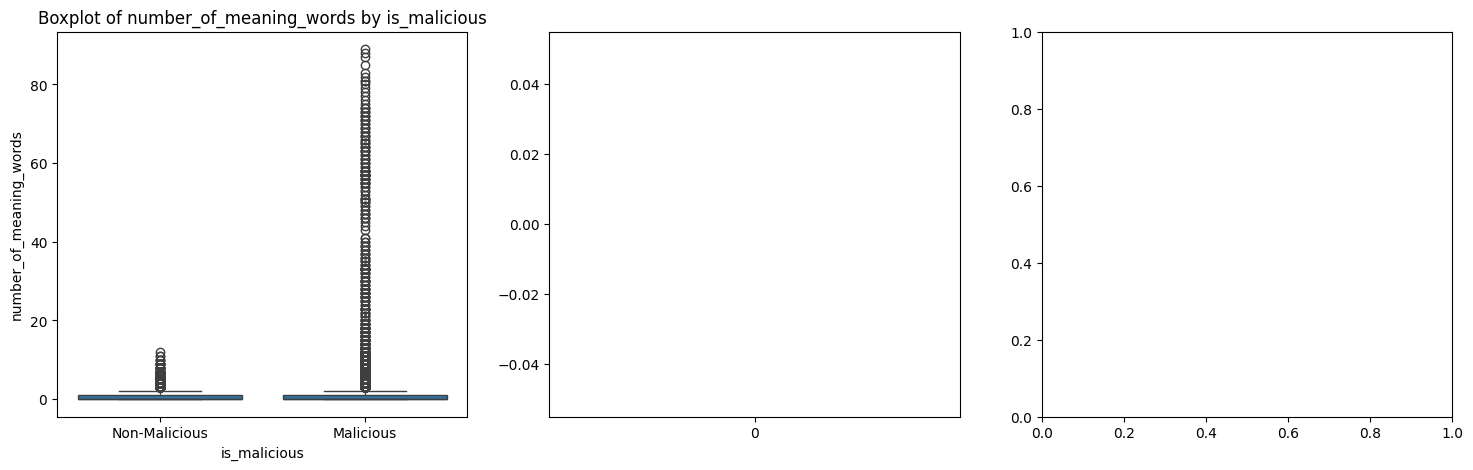

In [ ]:
##악성 여부에 따른 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns
#변수 목록
variables = ['number_of_meaning_words','blacklist_word_count']

fig, axes = plt.subplots(1,3,figsize=(18,5))
for i, var in enumerate(variables):
  sns.boxplot(data=train, x='label',y=var,ax=axes[i])
  axes[i].set_title(f'Boxplot of {var} by is_malicious')
  axes[i].set_xlabel('is_malicious')
  axes[i].set_ylabel(var)
  axes[i].set_xticks([0,1])
  axes[i].set_xticklabels(['Non-Malicious','Malicious'])
plt.tight_layout()
plt.show()

# 상관관계 분석

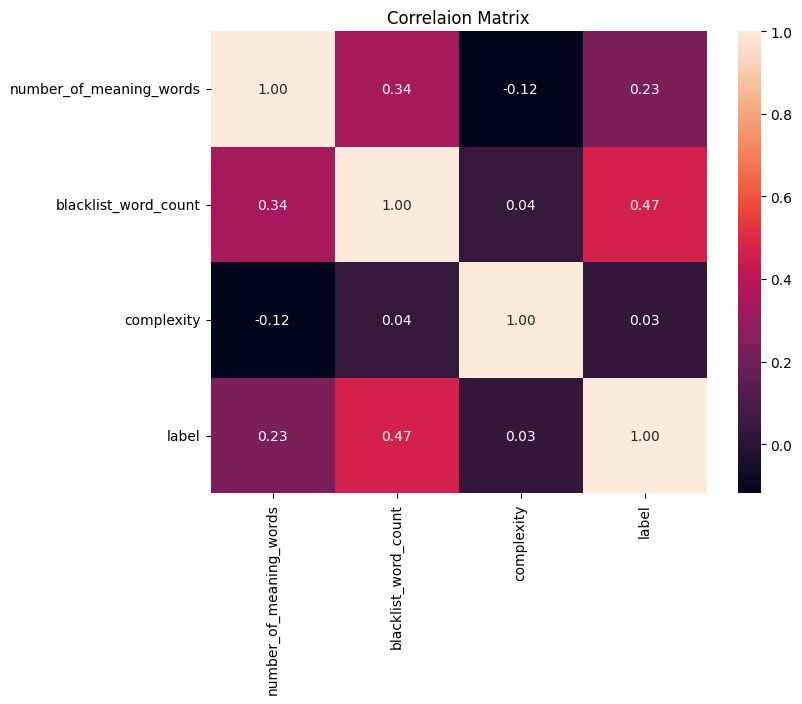

In [12]:
#상관관계 분석
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = train[['number_of_meaning_words','blacklist_word_count','complexity','label']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,fmt='.2f')
plt.title('Correlaion Matrix')
plt.show()

In [ ]:
train = train.dropna()